In [108]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [109]:
import sys
import torch, torch.nn as nn, torch.optim as optim
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
project_root = Path.cwd().resolve().parents[2]
sys.path.append(str(project_root))

from defs.vae.ae import *
from defs.vae.training_defs import *

In [110]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

spectra, fractions = load_spectral_data()
# train_loader, val_loader = get_dataloaders(spectra, fractions)
unbatched_data = get_dataloader_unbatched(spectra, fractions)
num_spectra = unbatched_data.dataset[0][0].size(0)
print(unbatched_data.batch_size)
print(num_spectra)

Device: cpu
1
210


In [111]:
convolution = ConvEncoder([unbatched_data.batch_size, 32, 32], [128, 128], c_d={'pad': 1}, num_spectra=num_spectra)
criterion = nn.MSELoss()
optimizer = optim.Adam(convolution.parameters(), lr=1e-3)

# print(convolution.encoder)
# print(convolution.decoder)

n_epochs = 10

In [112]:
losses = []
for epoch in range(1, n_epochs+1):
    convolution.train()
    tot_loss = 0
    for xb, yb in unbatched_data:
        xb = xb.to(device)
        optimizer.zero_grad()
        loss_pred = criterion(convolution(xb), xb)
        loss_pred.backward()
        optimizer.step()

        tot_loss += float(loss_pred)

    losses.append(tot_loss / len(unbatched_data.dataset))

print(losses)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([1, 210])) that is different to the input size (torch.Size([210])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


[0.006152125761983876, 0.004225786926224287, 0.004088865710513002, 0.0038532012954580765, 0.003872049270886816, 0.003871942056644707, 0.0037777865217978085, 0.0037040622318833764, 0.0037235190787732204, 0.0036742126587259428]


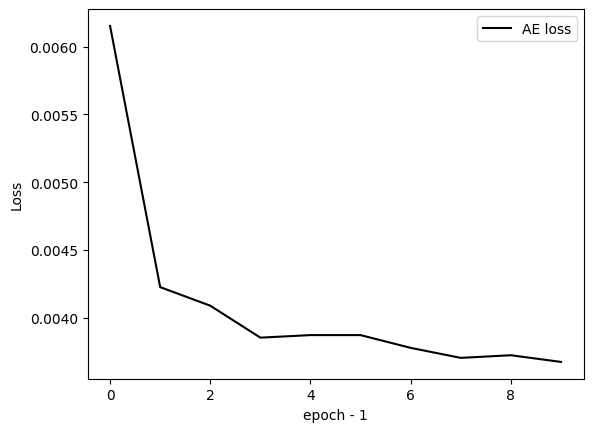

In [113]:
plt.plot(losses, color='black', label='AE loss')
plt.xlabel('epoch - 1'); plt.ylabel('Loss'); plt.legend()

In [124]:
val_spectrum = next(iter(unbatched_data))[0]
# print(val_spectrum)
# print(convolution(val_spectrum))
print(f'Absolute difference between model\'s reconstruction and actual spectrum:')
print(abs(convolution(val_spectrum)-val_spectrum))


Absolute difference between model's reconstruction and actual spectrum:
tensor([[0.0092, 0.0108, 0.0125, 0.0137, 0.0150, 0.0164, 0.0177, 0.0189, 0.0201,
         0.0206, 0.0217, 0.0230, 0.0239, 0.0256, 0.0265, 0.0274, 0.0281, 0.0291,
         0.0284, 0.0292, 0.0304, 0.0304, 0.0322, 0.0334, 0.0338, 0.0352, 0.0355,
         0.0366, 0.0365, 0.0385, 0.0378, 0.0354, 0.0349, 0.0367, 0.0417, 0.0430,
         0.0439, 0.0433, 0.0428, 0.0416, 0.0418, 0.0408, 0.0394, 0.0399, 0.0392,
         0.0398, 0.0400, 0.0380, 0.0377, 0.0362, 0.0340, 0.0334, 0.0338, 0.0304,
         0.0263, 0.0262, 0.0265, 0.0296, 0.0301, 0.0315, 0.0337, 0.0333, 0.0345,
         0.0342, 0.0354, 0.0337, 0.0349, 0.0345, 0.0347, 0.0322, 0.0312, 0.0276,
         0.0210, 0.0181, 0.0200, 0.0230, 0.0255, 0.0298, 0.0308, 0.0327, 0.0331,
         0.0329, 0.0321, 0.0335, 0.0330, 0.0338, 0.0322, 0.0323, 0.0317, 0.0330,
         0.0319, 0.0306, 0.0301, 0.0287, 0.0234, 0.0146, 0.0176, 0.0080, 0.0031,
         0.0107, 0.0262, 0.0239, 0.00